In [1]:
%matplotlib widget

In [2]:
from pathlib import Path

import h5py
import numpy as np
from numpy.typing import NDArray
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DPI = plt.rcParams['figure.dpi']

---

In [3]:
def signal_rectify(signal_data: NDArray) -> NDArray:
    return np.abs(signal_data)

def normalise_signal(signal_data: NDArray) -> NDArray:
    return (signal_data - signal_data.mean()) / signal_data.std()

def envelope_signal(signal_data: NDArray, sampling_rate: int, low_threshold: float) -> NDArray:
    low_pass = low_threshold / (sampling_rate / 2)
    b, a = signal.butter(4, low_pass, btype='lowpass')
    return signal.filtfilt(b, a, signal_data)

In [4]:
def label_emg_activity_by_exercises(
    emg_signal: NDArray,
    sampling_rate: int,
    high_threshold: float = 2.0,
    low_threshold: float = 1.0,
    min_event_duration_sec: float = 2,
    max_event_duration_sec: float = 4.8,
    min_gap_sec: float = 9,
    stop_if_labels_end: bool = True,
) -> list[tuple[int, int]]:

    n_samples = len(emg_signal)

    min_event_samples = int(round(min_event_duration_sec * sampling_rate))
    min_gap_samples = int(round(min_gap_sec * sampling_rate))

    min_event_samples = max(min_event_samples, 1)
    min_gap_samples = max(min_gap_samples, 0)

    raw_events = []

    in_event = False
    event_start = None
    event_dur = 0

    for i, value in enumerate(emg_signal ** 3):
        if not np.isfinite(value):
            value = -np.inf

        if not in_event and value >= high_threshold:
            in_event = True
            event_start = i
            event_dur = 0

        elif in_event and (value <= low_threshold or event_dur / sampling_rate > max_event_duration_sec):
            event_end = i
            raw_events.append((event_start, event_end))
            in_event = False
            event_start = None
        
        event_dur += 1

    if in_event and event_start is not None:
        raw_events.append((event_start, n_samples))

    filtered_events = []

    for start, end in raw_events:
        if end - start >= min_event_samples:
            filtered_events.append((start, end))

    merged_events = []

    for start, end in filtered_events:
        if not merged_events:
            merged_events.append([start, end])
            continue

        previous_start, previous_end = merged_events[-1]
        gap = start - previous_end

        if gap <= min_gap_samples:
            merged_events[-1][1] = end
        else:
            merged_events.append([start, end])

    merged_events = [(int(start), int(end)) for start, end in merged_events]

    return merged_events

In [5]:
def detect_emg_events(
    emg,
    fs,
    min_event_duration_s=0.2,
    max_event_duration_s=5.0,
    min_pause_duration_s=0.2,
    max_pause_duration_s=None,
    start_threshold=0.5,
    stop_threshold=0.3,
    confirm_duration_s=0.5,
    return_seconds=False
):
    """
    Выделяет события мышечной активности из сглаженного и нормализованного ЭМГ-сигнала.

    Parameters
    ----------
    emg : array-like, shape [n_samples]
        Одномерный сглаженный и нормализованный ЭМГ-сигнал.

    fs : float
        Частота дискретизации сигнала, Гц.

    min_event_duration_s : float
        Минимальная длительность события, секунды.
        События короче этого значения отбрасываются.

    max_event_duration_s : float
        Максимальная длительность события, секунды.
        Если событие длится дольше, оно принудительно завершается.

    min_pause_duration_s : float
        Минимальная длительность перерыва между событиями, секунды.
        Если перерыв меньше этого значения, соседние события объединяются.

    max_pause_duration_s : float or None
        Максимальная длительность перерыва, секунды.
        В текущей логике используется только как справочный параметр.
        Основное влияние оказывает min_pause_duration_s.

    start_threshold : float
        Порог начала события.
        Событие начинается, если сигнал держится выше этого порога
        не менее confirm_duration_s.

    stop_threshold : float
        Порог окончания события.
        Событие заканчивается, если сигнал держится ниже этого порога
        не менее confirm_duration_s.

    confirm_duration_s : float
        Длительность подтверждения условия старта/завершения, секунды.
        По условию задачи — 0.5 секунды.

    return_seconds : bool
        Если False, возвращаются индексы отсчётов.
        Если True, возвращаются времена в секундах.

    Returns
    -------
    events : list of tuple
        Список событий вида:
        [(start_idx, end_idx), ...]
        или, если return_seconds=True:
        [(start_time_s, end_time_s), ...]
    """

    emg = np.asarray(emg, dtype=float)

    if emg.ndim != 1:
        raise ValueError("emg должен быть одномерным массивом.")

    if fs <= 0:
        raise ValueError("fs должен быть положительным числом.")

    if stop_threshold > start_threshold:
        raise ValueError(
            "stop_threshold должен быть меньше или равен start_threshold. "
            "Иначе гистерезис будет работать некорректно."
        )

    n_samples = len(emg)

    confirm_samples = int(round(confirm_duration_s * fs))
    min_event_samples = int(round(min_event_duration_s * fs))
    max_event_samples = int(round(max_event_duration_s * fs))
    min_pause_samples = int(round(min_pause_duration_s * fs))

    confirm_samples = max(confirm_samples, 1)
    min_event_samples = max(min_event_samples, 1)
    max_event_samples = max(max_event_samples, min_event_samples)
    min_pause_samples = max(min_pause_samples, 0)

    events = []

    in_event = False
    event_start = None

    above_count = 0
    below_count = 0

    i = 0

    while i < n_samples:
        value = emg[i]

        if not in_event:
            # Проверяем устойчивое превышение порога старта
            if value >= start_threshold:
                above_count += 1
            else:
                above_count = 0

            # Если сигнал держался выше порога достаточно долго,
            # считаем, что событие началось в начале этого устойчивого участка
            if above_count >= confirm_samples:
                event_start = i - confirm_samples + 1
                in_event = True
                below_count = 0

        else:
            event_duration = i - event_start + 1

            # Проверяем устойчивое падение ниже порога завершения
            if value <= stop_threshold:
                below_count += 1
            else:
                below_count = 0

            stop_by_threshold = below_count >= confirm_samples
            stop_by_max_duration = event_duration >= max_event_samples

            if stop_by_threshold:
                # Конец события ставим перед устойчивым участком покоя
                event_end = i - confirm_samples + 1

                duration = event_end - event_start

                if duration >= min_event_samples:
                    events.append((event_start, event_end))

                in_event = False
                event_start = None
                above_count = 0
                below_count = 0

            elif stop_by_max_duration:
                event_end = event_start + max_event_samples

                duration = event_end - event_start

                if duration >= min_event_samples:
                    events.append((event_start, min(event_end, n_samples - 1)))

                in_event = False
                event_start = None
                above_count = 0
                below_count = 0

        i += 1

    # Если запись закончилась во время события
    if in_event and event_start is not None:
        event_end = n_samples - 1
        duration = event_end - event_start

        if duration >= min_event_samples:
            events.append((event_start, event_end))

    # Объединение событий, если пауза между ними слишком короткая
    events = merge_close_events(
        events,
        min_pause_samples=min_pause_samples
    )

    # Финальная фильтрация по минимальной и максимальной длительности
    events = filter_events_by_duration(
        events,
        min_duration_samples=min_event_samples,
        max_duration_samples=max_event_samples
    )

    if return_seconds:
        events = [
            (start / fs, end / fs)
            for start, end in events
        ]

    return events


def merge_close_events(events, min_pause_samples):
    """
    Объединяет соседние события, если пауза между ними меньше min_pause_samples.
    """

    if len(events) == 0:
        return []

    merged = [events[0]]

    for start, end in events[1:]:
        prev_start, prev_end = merged[-1]

        pause = start - prev_end

        if pause < min_pause_samples:
            merged[-1] = (prev_start, end)
        else:
            merged.append((start, end))

    return merged


def filter_events_by_duration(
    events,
    min_duration_samples,
    max_duration_samples
):
    """
    Оставляет только события с допустимой длительностью.
    """

    filtered = []

    for start, end in events:
        duration = end - start

        if min_duration_samples <= duration <= max_duration_samples:
            filtered.append((start, end))

    return filtered

In [162]:
tmp_data_folder = Path('./tmp/data')
participant_code = 22
data_file = tmp_data_folder / f'{participant_code}/{participant_code}.hdf5'

In [177]:
with h5py.File(data_file, mode='r') as hdf_file:
    channel_data: NDArray[np.float32] = np.asarray(hdf_file.get('emg')[:, 90], dtype=np.float32)
    exercises_data: NDArray[np.int8] = np.asarray(hdf_file.get('markup')[:], dtype=np.int8)

channel_data = normalise_signal(signal_rectify(channel_data))
channel_data = envelope_signal(channel_data, sampling_rate=1024, low_threshold=3)

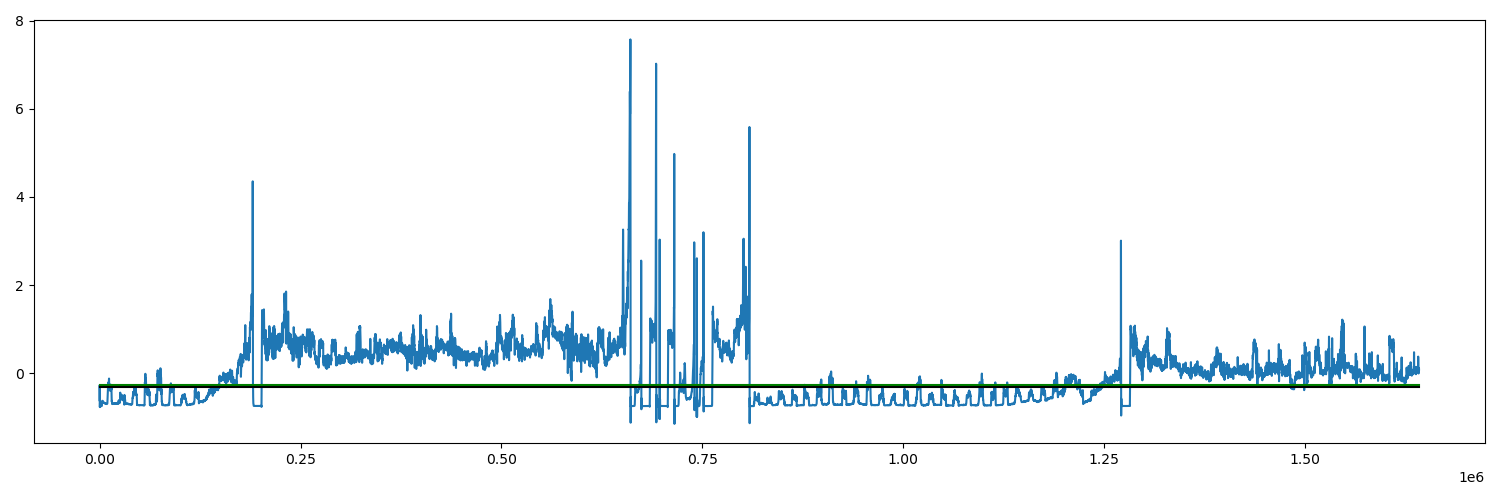

In [178]:
plt.close()
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_size_inches(w=1500 / DPI, h=500 / DPI)

high_threshold = -0.27
low_threshold = -0.32

ax.plot(channel_data)
ax.add_line(Line2D((0, len(channel_data)), (high_threshold, high_threshold), c='g'))
ax.add_line(Line2D((0, len(channel_data)), (low_threshold, low_threshold), c='k'))

fig.tight_layout()
plt.show()

In [154]:
events = detect_emg_events(
    emg=channel_data,
    fs=1024,
    min_event_duration_s=3,
    max_event_duration_s=6.0,
    min_pause_duration_s=7,
    max_pause_duration_s=10,
    start_threshold=high_threshold,
    stop_threshold=low_threshold,
    confirm_duration_s=0.5,
    return_seconds=False
)

In [159]:
events_indeces = np.zeros_like(channel_data, dtype=np.int8)

for start, end in events:
    events_indeces[start: end] = 1

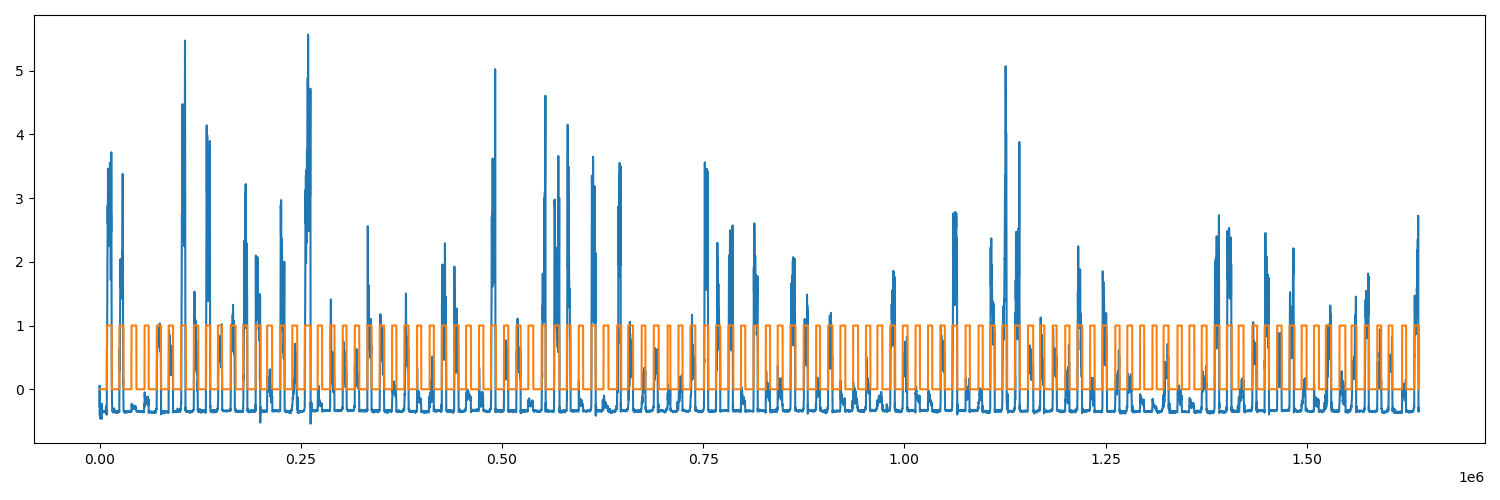

In [160]:
plt.close()
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_size_inches(w=1500 / DPI, h=500 / DPI)

ax.plot(channel_data)
ax.plot(events_indeces)

fig.tight_layout()
plt.show()

In [158]:
events = [
    (8958, 15102),
 (24521, 29738),
    (39530, 45700),
 (55822, 60987),
 (70941, 76395),
 (85765, 91276),
 (101100, 107244),
 (117057, 122644),
 (132054, 137430),
 (146983, 152090),
 (162842, 168986),
 (178473, 183540),
 (193913, 200057),
 (208160, 214304),
 (224460, 230067),
 (239378, 245522),
 (254905, 262150),
 (270960, 276437),
 (286444, 291868),
 (302055, 306810),
 (316969, 322599),
 (332728, 337992),
 (348006, 353595),
 (363330, 368712),
 (378587, 383880),
 (394365, 399614),
 (410022, 415330),
 (425164, 430656),
 (440572, 446100),
 (455253, 461397),
 (471327, 476845),
 (486261, 492405),
 (502352, 507787),
 (517805, 523177),
 (532700, 538844),
 (549233, 554130),
 (564677, 571130),
 (580524, 585295),
 (595290, 600758),
 (610985, 616240),
 (626075, 632219),
 (642918, 648076),
 (656685, 662829),
 (673512, 678170),
 (688511, 694655),
 (705713, 709130),
 (719227, 724275),
 (734076, 740220),
 (750934, 756271),
 (765864, 771244),
 (781282, 787426),
 (796913, 802230),
 (812455, 817964),
 (827736, 833068),
 (842509, 848653),
 (858423, 864567),
 (874769, 879960),
 (890290, 895100),
 (905105, 910699),
 (920385, 926529),
 (936240, 942384),
 (952174, 957655),
 (966388, 972532),
 (982333, 988477),
 (997806, 1003950),
 (1013731, 1019232),
 (1029256, 1034523),
 (1044816, 1050210),
 (1059352, 1065496),
 (1075933, 1081281),
 (1092002, 1097276),
 (1106636, 1112230),
 (1121470, 1127614),
 (1137265, 1143409),
 (1153468, 1159970),
 (1168604, 1173824),
 (1184150, 1189100),
 (1199761, 1205114),
 (1214884, 1221028),
 (1230693, 1236252),
 (1246031, 1251420),
 (1261952, 1267392),
 (1276914, 1283058),
 (1292731, 1297862),
 (1308095, 1313381),
 (1321967, 1328111),
 (1339248, 1344681),
 (1354040, 1360184),
 (1369361, 1375505),
 (1385349, 1391493),
 (1400637, 1406781),
 (1415188, 1421332),
 (1432101, 1438245),
 (1447514, 1452966),
 (1463096, 1468678),
 (1478422, 1484566),
 (1493518, 1499662),
 (1508838, 1514982),
 (1523528, 1530180),
 (1540529, 1547830),
 (1555475, 1561619),
 (1571865, 1577270),
 (1587461, 1592390),
 (1601502, 1606280),
 (1618333, 1623311),
 (1633412, 1639423)
]

In [161]:
exercises_arr = np.zeros_like(channel_data, dtype=np.int8)

for exercise, (start, stop) in zip(exercises_data, events):
    exercises_arr[start: stop] = exercise

np.save(data_file.parent / 'markup.npy', exercises_arr)